In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing scanpy
!pip install scanpy
import scanpy as sc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.4/255.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 4.0 MB/s eta 0:00:00


In [ ]:
# Read in data
adata = sc.read_h5ad('/content/drive/MyDrive/bence_project_july/MMP3_CONT1_adata.h5ad')


In [ ]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
# Identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('mt-')  # mouse
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

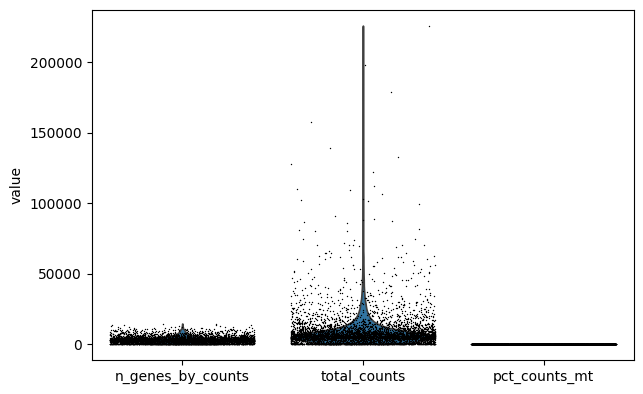

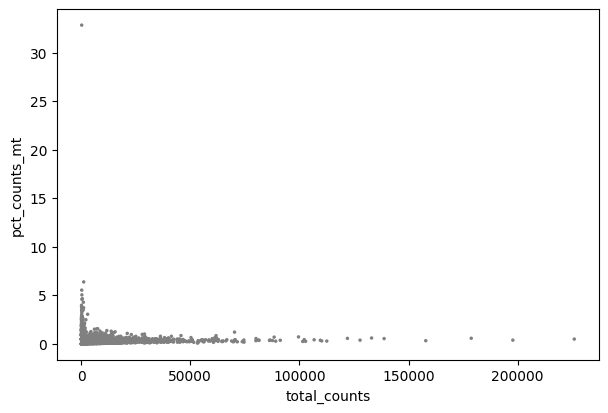

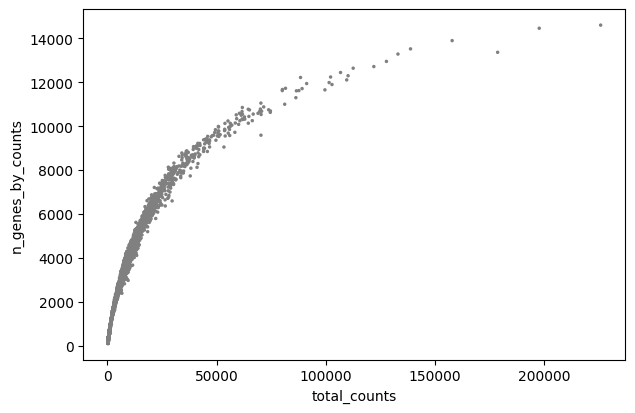

In [ ]:
# Visualise before QC
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

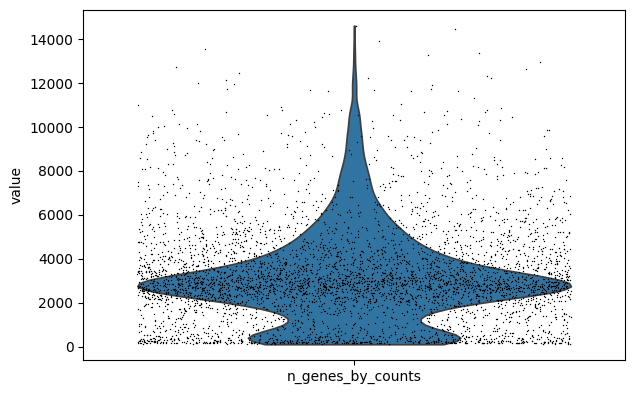

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4)

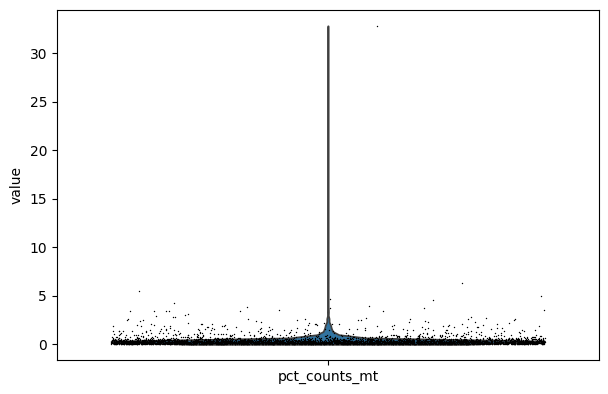

In [ ]:
sc.pl.violin(adata, ['pct_counts_mt'], jitter=0.4)

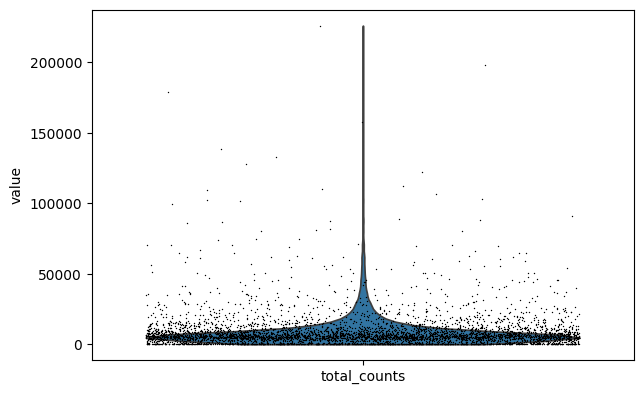

In [ ]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4)

In [ ]:
# Filter
adata = adata[adata.obs.n_genes_by_counts < 6000, :]
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

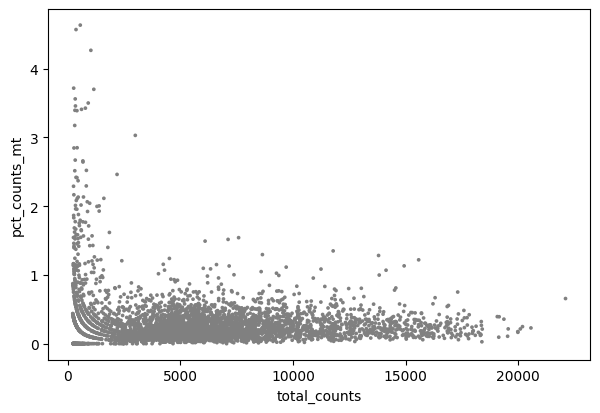

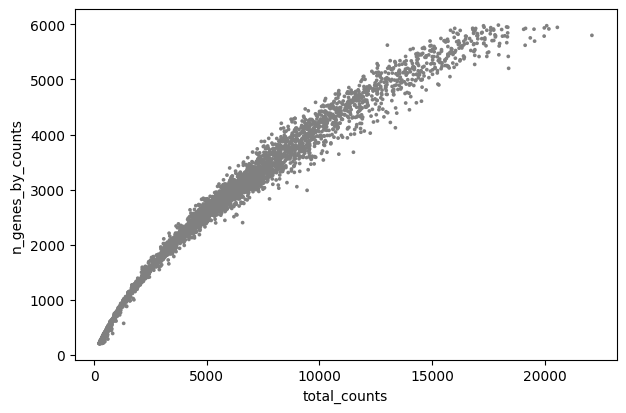

In [ ]:
# Visualise after filtering
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [ ]:
sc.pp.filter_genes(adata, min_cells=3)

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [ ]:
!pip install scrublet
import scrublet as scr
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551515 sha256=f140a713d313176676b4b4740a10d896f842893f5b85ef83e07ae39a37e51b24
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


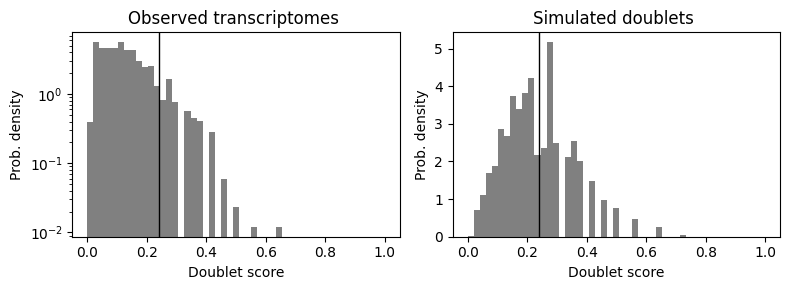

In [ ]:
# Scrublet to label doublets
# Plot scrublet scores

sc.pp.scrublet(adata, expected_doublet_rate=0.1,threshold=0.24)
sc.pl.scrublet_score_distribution(adata)

In [ ]:
predicted_doublets = adata.obs['doublet_score'] > 0.24
print(predicted_doublets.sum() / len(adata))

0.10397111913357401


In [ ]:
# Annotate the doublets with TRUE/FALSE in a 'predicted_doublet' column based on their 'doublet_score'
adata.obs['predicted_doublet'] = adata.obs['doublet_score'] > 0.24

In [ ]:
# Save .h5ad file with annotated doublets
adata.write('/content/drive/MyDrive/bence_project_july/bence_project_july_output_files/MMP3_CONT1_adata_with_doublets.h5ad')

In [ ]:
# Remove predicted doublets
adata = adata[~adata.obs['predicted_doublet'], :].copy()

In [ ]:
# Normalise and log transform

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)

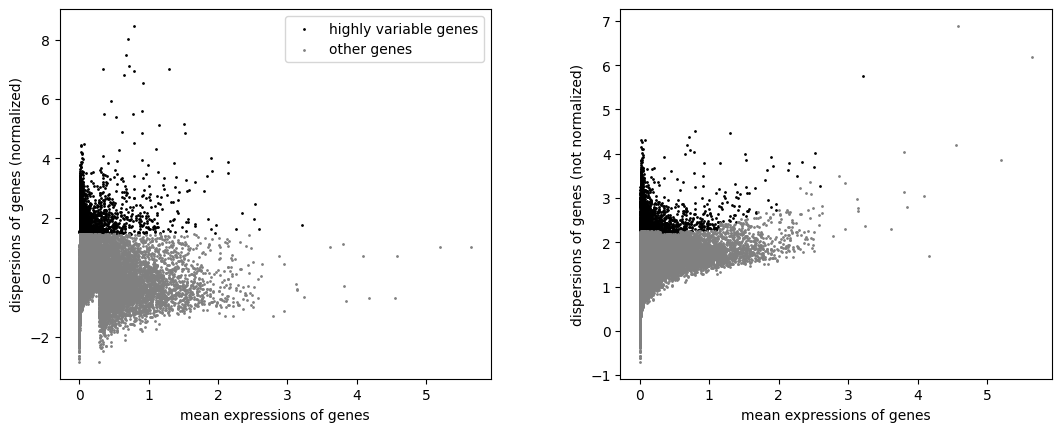

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
# Scale data
sc.pp.scale(adata, max_value=10)
# Can regress out cell cycle stage here etc if wanted:
# sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# Cluster using highly variable genes
sc.tl.pca(adata, use_highly_variable=True)
var_ratio = adata.uns['pca']['variance_ratio']

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


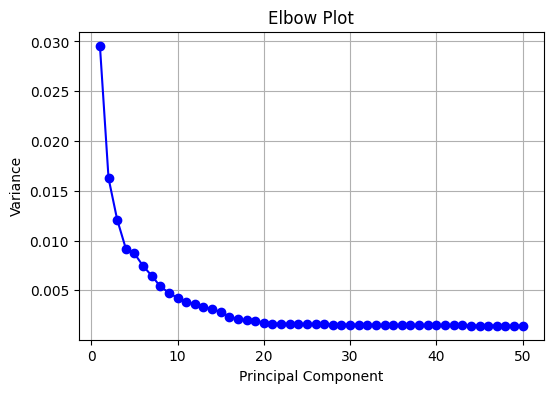

In [ ]:
# Elbow plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(var_ratio)+1), var_ratio, 'o-', color='blue')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Elbow Plot')
plt.grid(True)
plt.show()

In [ ]:
# Neighbours after choosing the number of principal components
sc.pp.neighbors(adata, n_pcs=20)

In [ ]:
!pip install python-igraph
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.8 MB/s eta 0:00:00


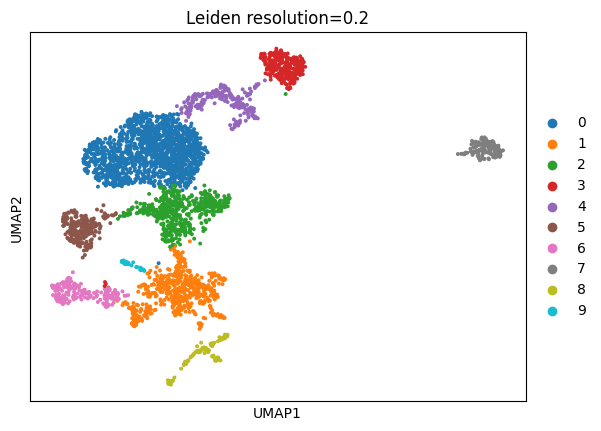

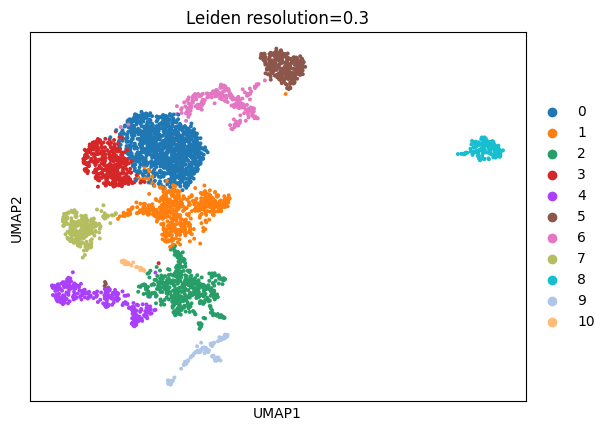

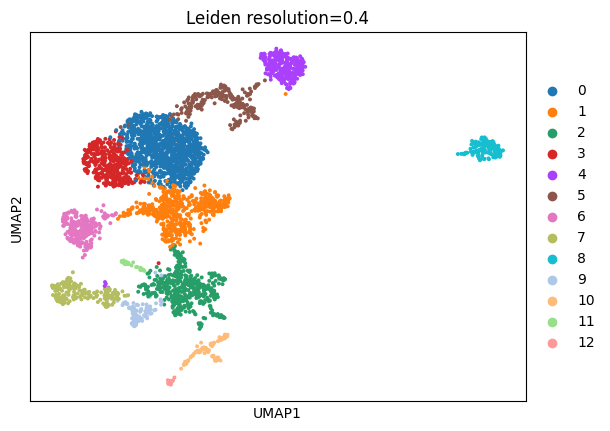

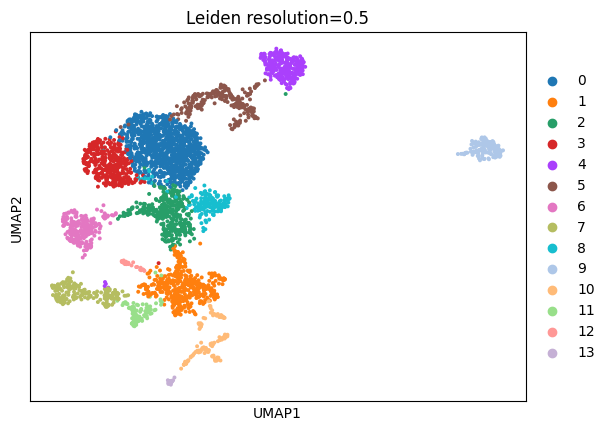

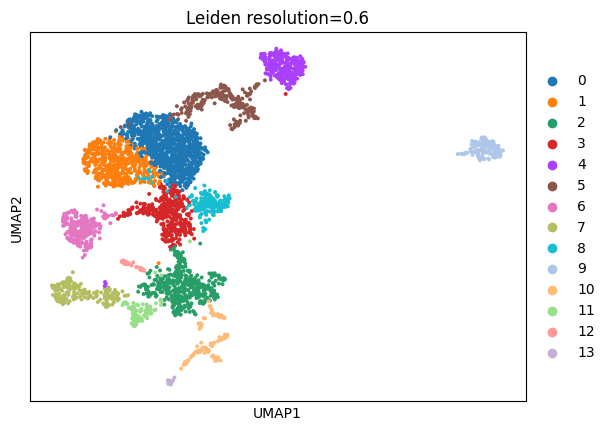

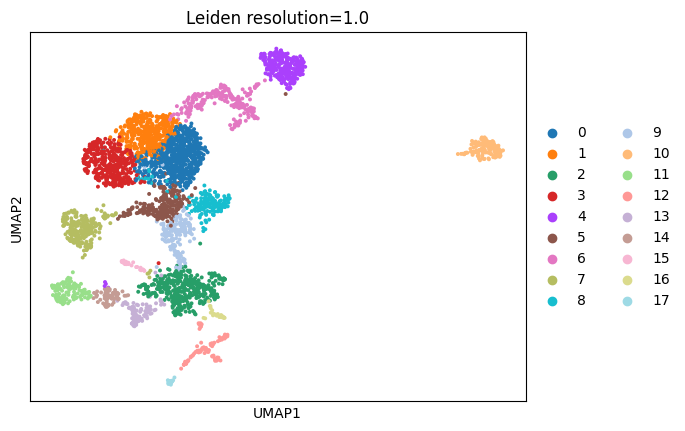

In [ ]:
# Test resolutions for clustering

sc.tl.umap(adata)

for res in [0.2,0.3,0.4,0.5,0.6, 1.0]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
    sc.pl.umap(adata, color=f'leiden_{res}', title=f'Leiden resolution={res}')

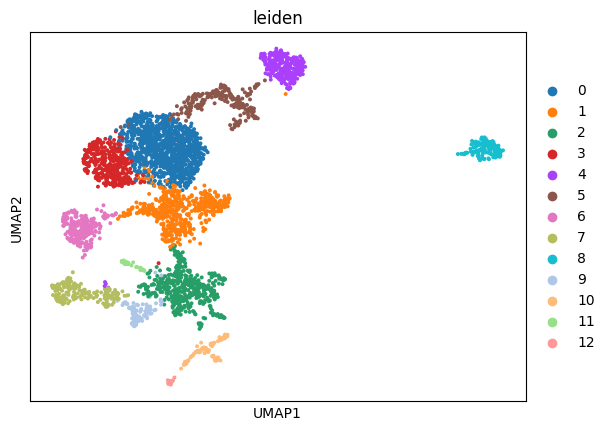

In [ ]:
sc.tl.leiden(adata, resolution=0.4)
sc.pl.umap(adata, color='leiden')

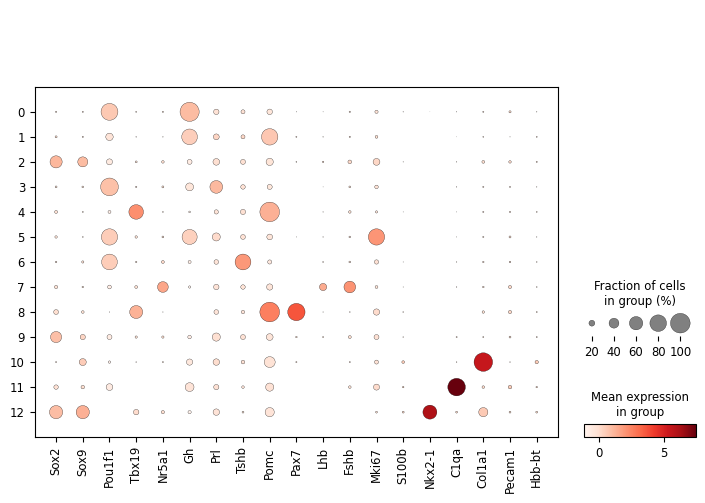

In [ ]:
# Dotplot of key cell-type markers
genes = [
    'Sox2', 'Sox9', 'Pou1f1','Tbx19', 'Nr5a1', 'Gh', 'Prl', 'Tshb',
    'Pomc', 'Pax7', 'Lhb', 'Fshb','Mki67', 'S100b', 'Nkx2-1', 'C1qa', 'Col1a1','Pecam1', 'Hbb-bt'
]

sc.pl.dotplot(adata, var_names=genes, groupby='leiden') #dendrogram=True

In [ ]:
from typing_extensions import clear_overloads
# Labelling cell types based on marker gene expression
0 - Pou1f1, Gh - Somatotrophs
1 - Pou1f1, Gh, Pomc - ????????????
2 - Sox2, Sox9 - Stem Cells
3 - Pou1f1, Prl - Lactotrophs
4 - Tbx19, Pomc - Corticotrophs
5 - Pou1f1, Gh, Mki67 - Proliferating Somatotrophs
6 - Pou1f1, Tshb - Thyrotrophs
7 - Nr5a1, Lhb, Fshb - Gonadotrophs
8 - Tbx19, Pomc, Pax7 - Melanotrophs
9 - Sox2, Sox9 - Stem Cells
10 - Col1a1 - Mesenchymal Cells
11 - C1qa - Immune Cells
12 - Sox2, Sox9, Nkx2-1 - Posterior????????

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: 

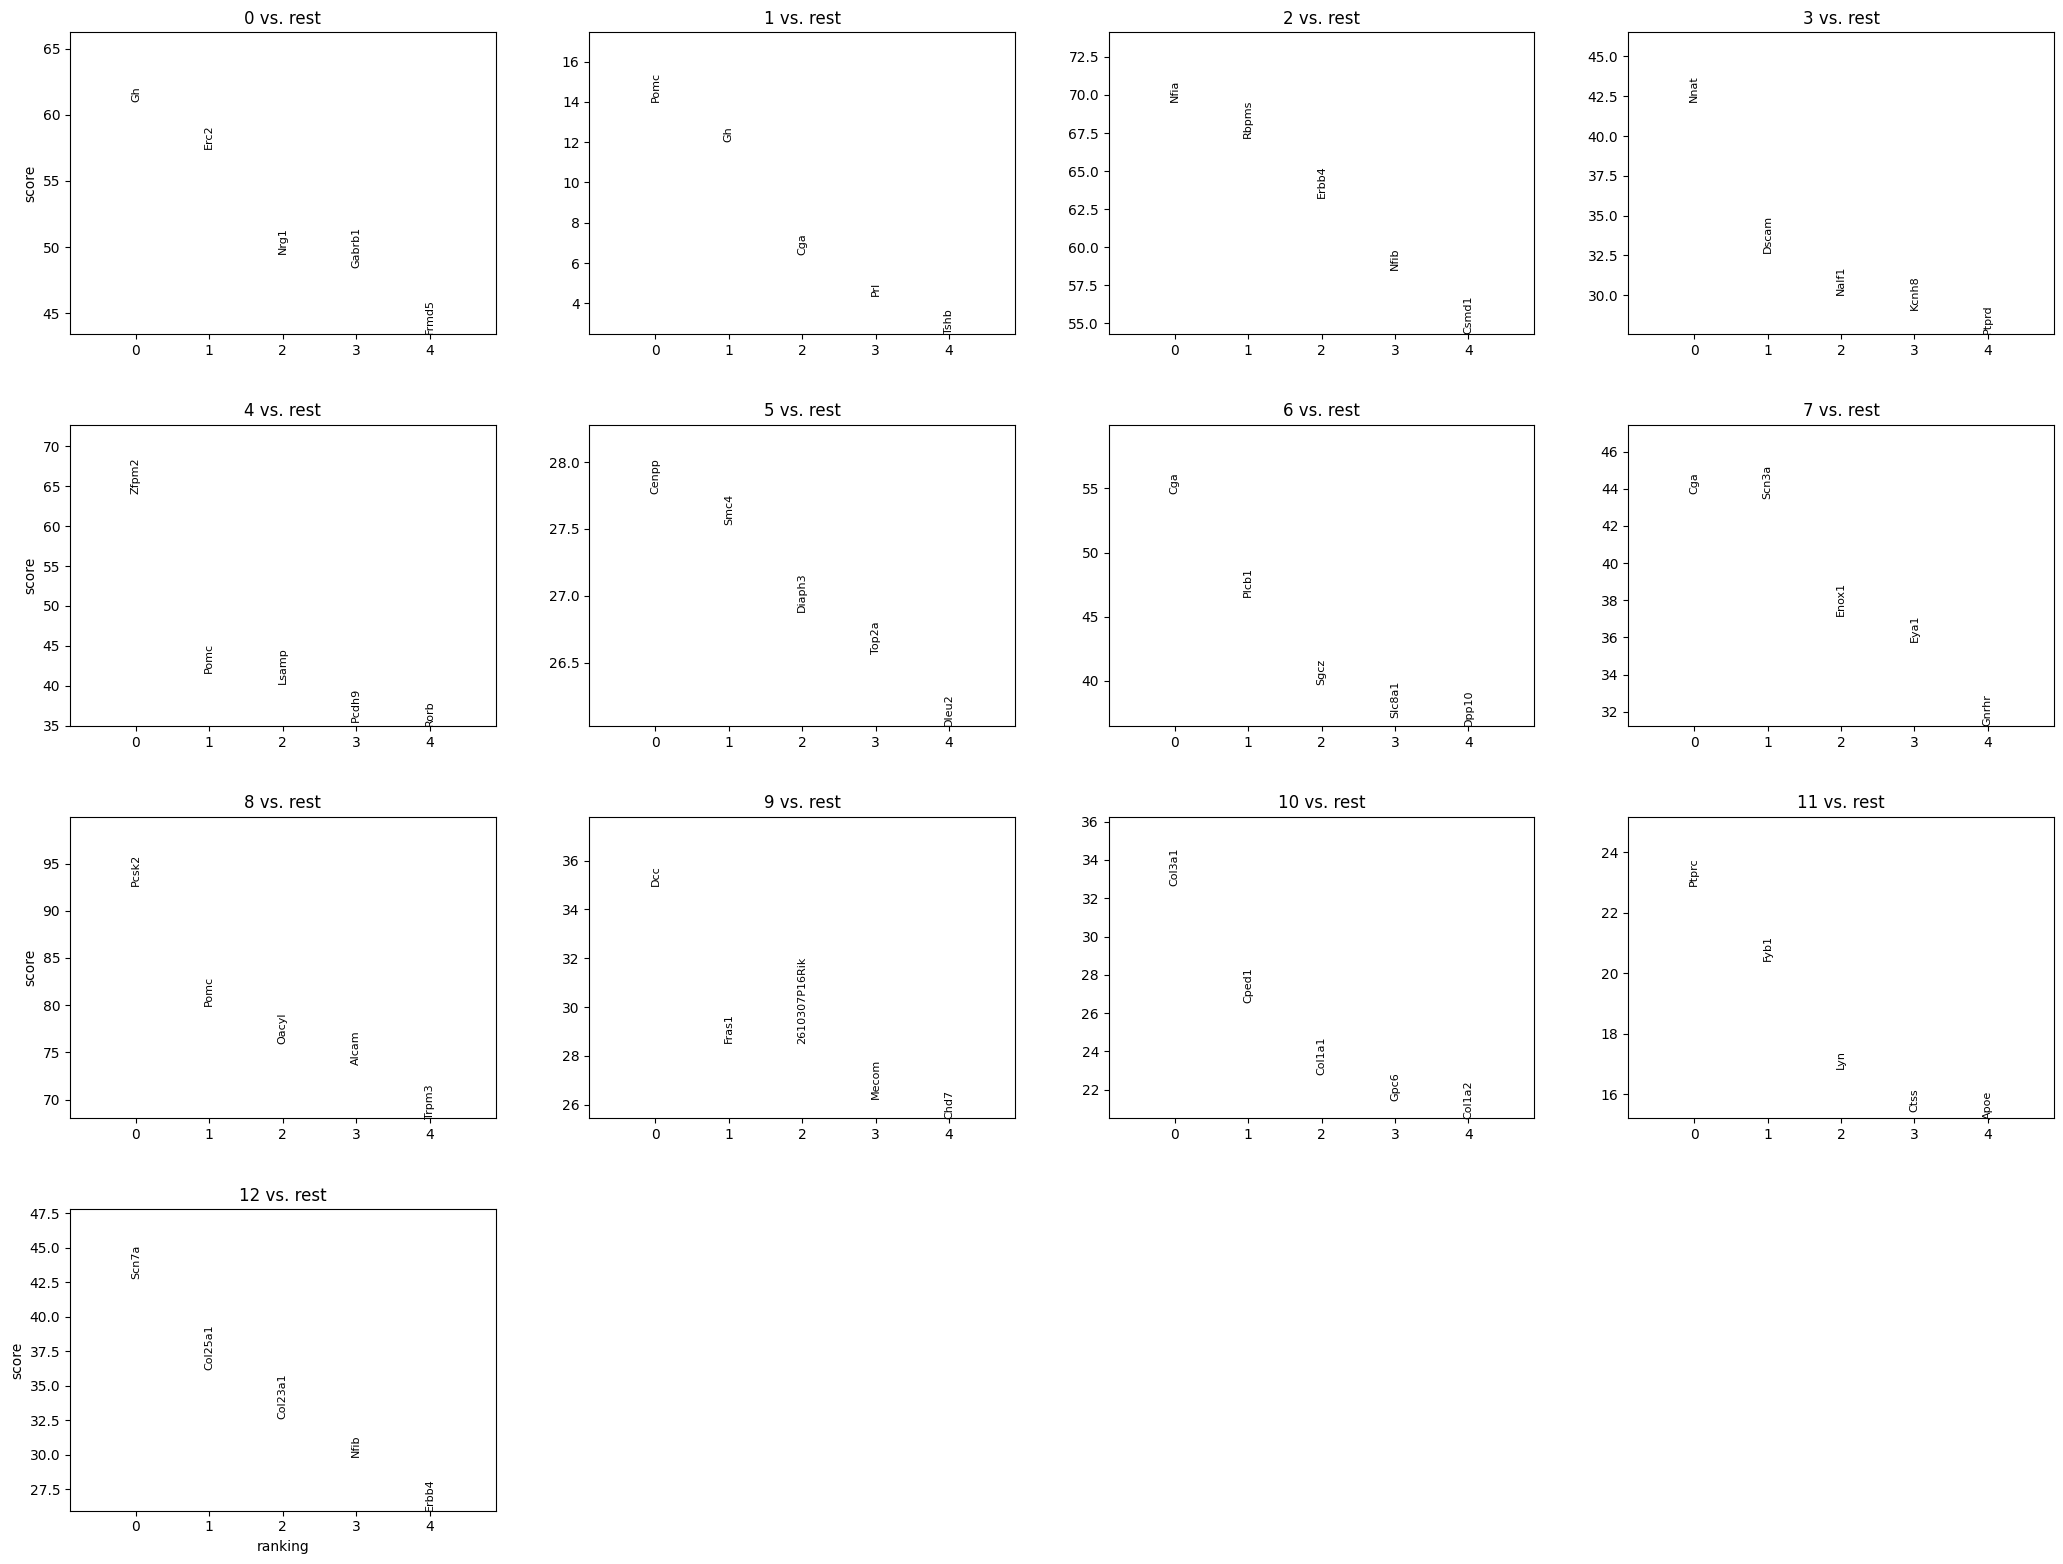

In [ ]:
# Check top 5 markers of each cluster
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

cell_type
Somatotrophs                 1862
Stem Cells                    562
Lactotrophs                   346
Corticotrophs                 269
Thyrotrophs                   214
Gonadotrophs                  194
Melanotrophs                  142
Mesenchymal Cells              83
Immune Cells                   29
Posterior Pituitary Cells      22
Name: count, dtype: int64


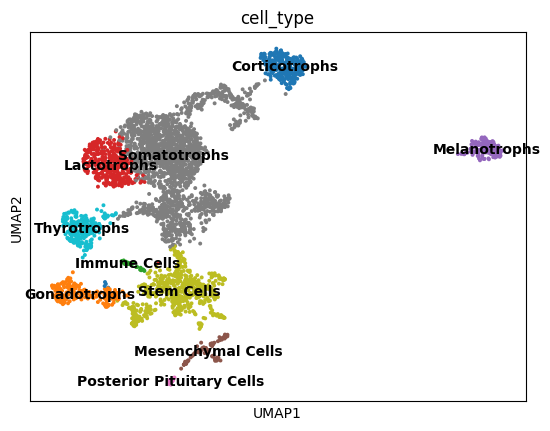

In [ ]:
# Assigning names to clusters
cluster_names = {
    '0': 'Somatotrophs',
    '1': 'Somatotrophs',
    '2': 'Stem Cells',
    '3': 'Lactotrophs',
    '4': 'Corticotrophs',
    '5': 'Somatotrophs',
    '6': 'Thyrotrophs',
    '7': 'Gonadotrophs',
    '8': 'Melanotrophs',
    '9': 'Stem Cells',
    '10': 'Mesenchymal Cells',
    '11': 'Immune Cells',
    '12': 'Posterior Pituitary Cells'
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_names).astype('category')
# Check
print(adata.obs['cell_type'].value_counts())

sc.pl.umap(adata, color='cell_type', legend_loc='on data')



# NOTES ON THIS DATASET
## Cluster 1 wasn't obvious so I went with Somato
## Cluster 5 is proliferating but I grouped together with other Somato clusters
## Cluster 12 I would label as posterior because of neural TF marker Nkx2-1 exp, this may need changing

In [ ]:
adata.write('/content/drive/MyDrive/bence_project_july/bence_project_july_output_files/MMP3_CONT1_adata_annotated.h5ad')

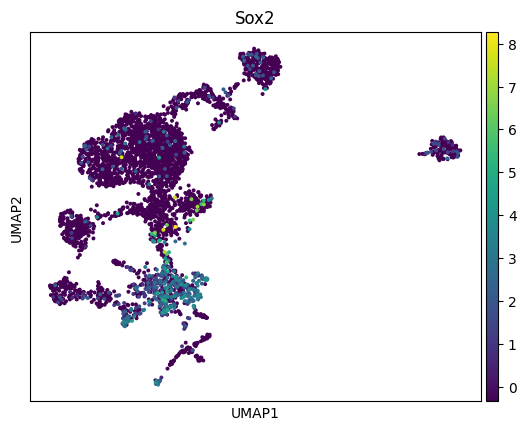

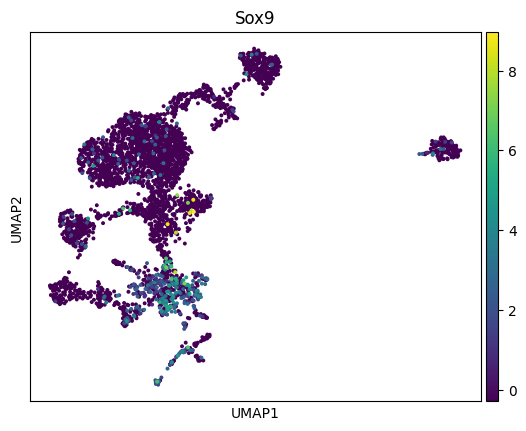

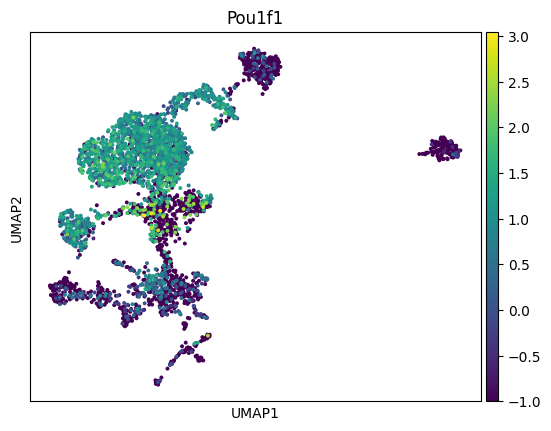

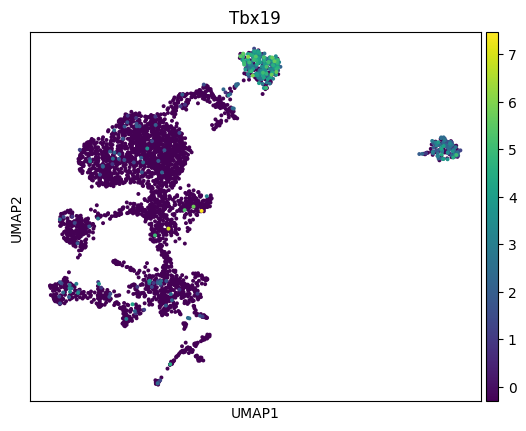

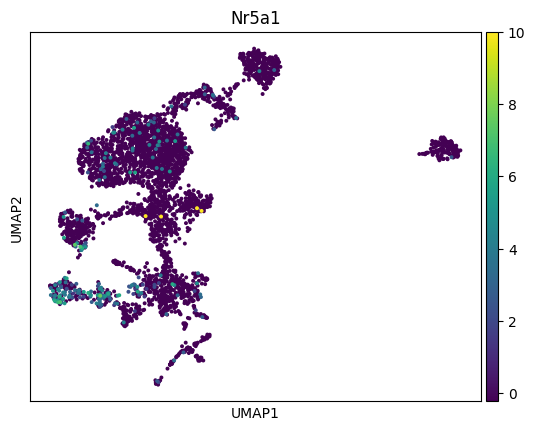

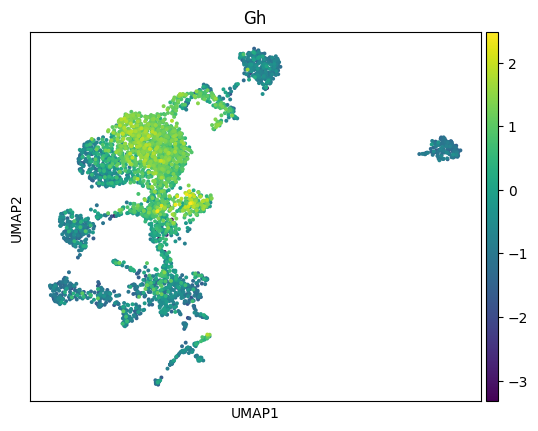

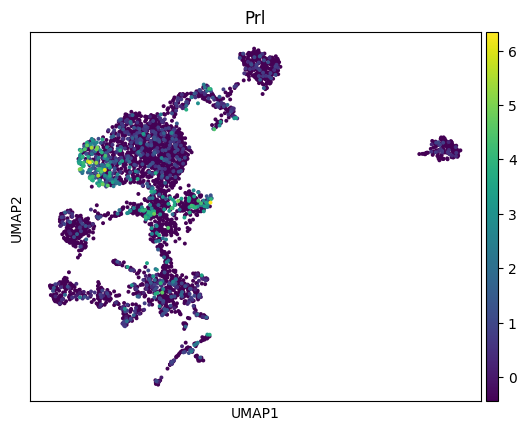

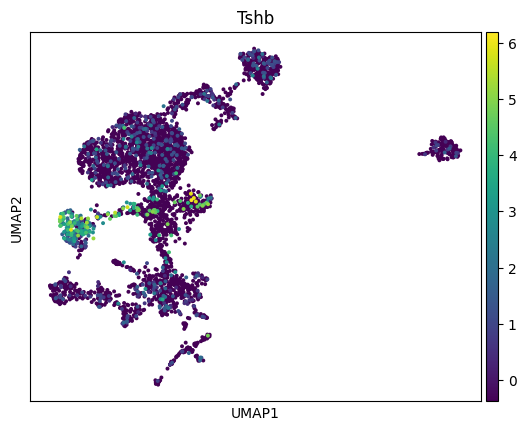

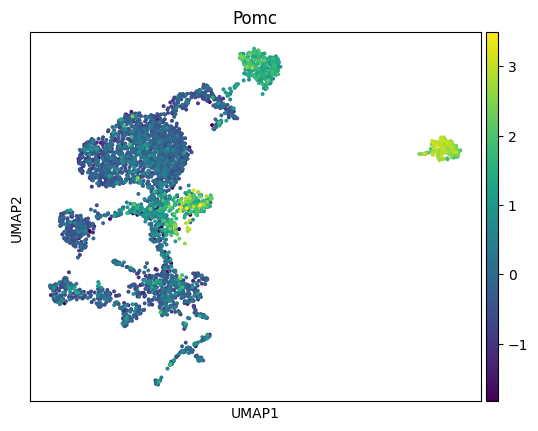

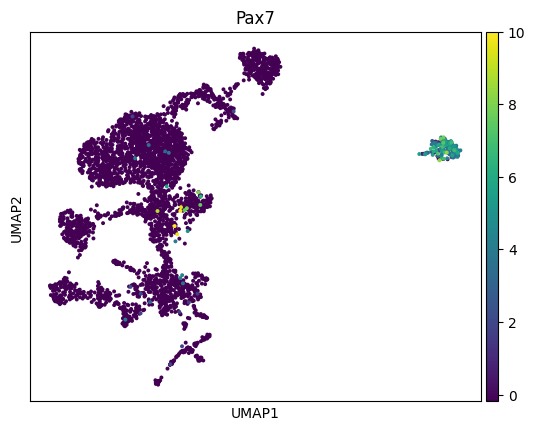

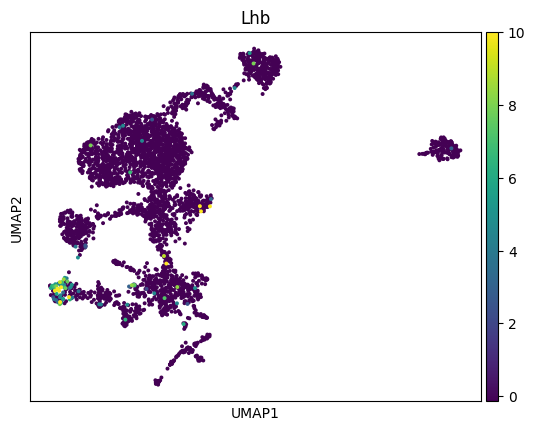

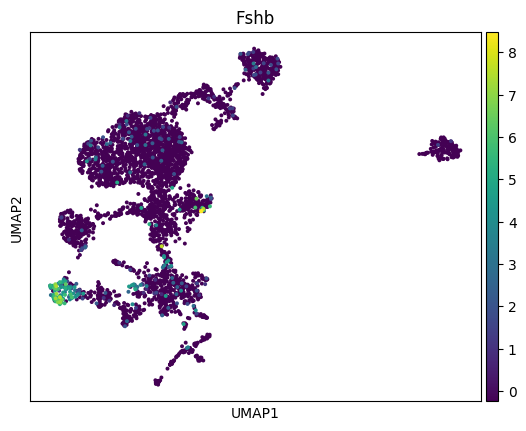

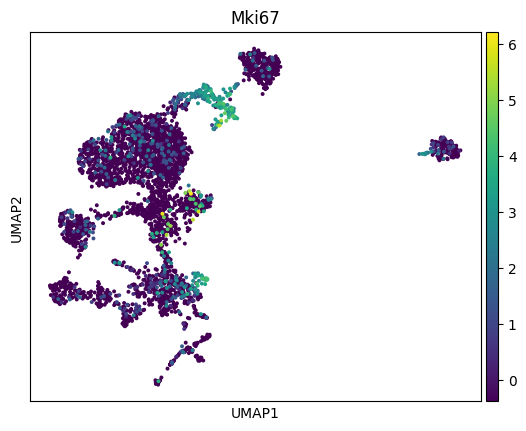

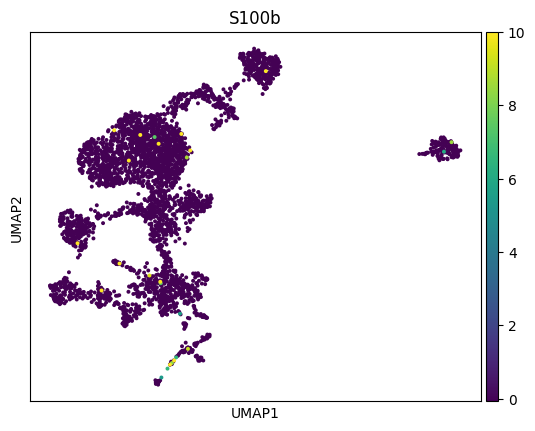

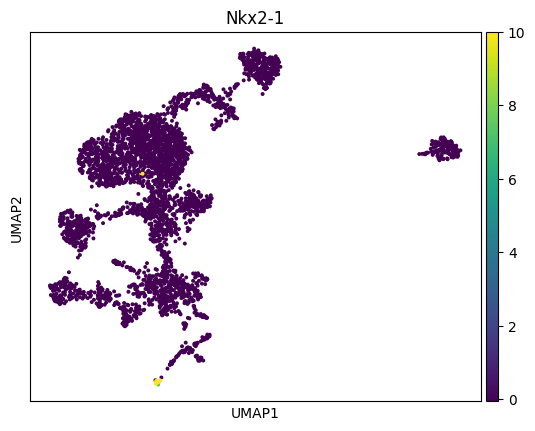

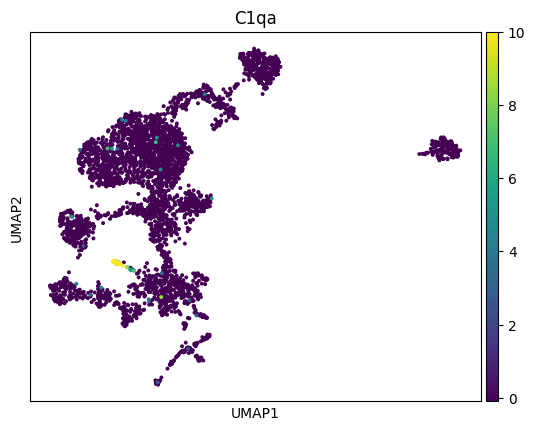

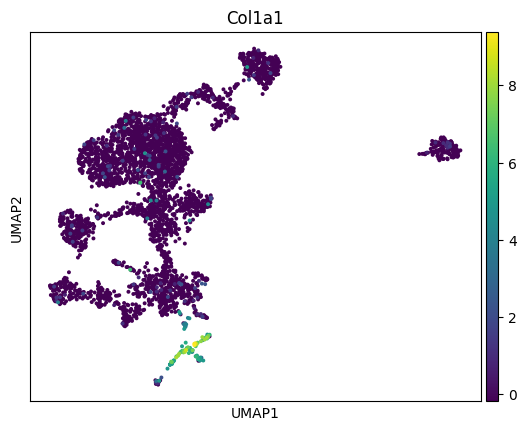

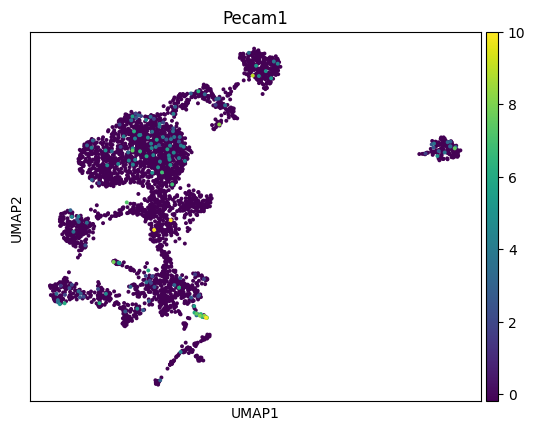

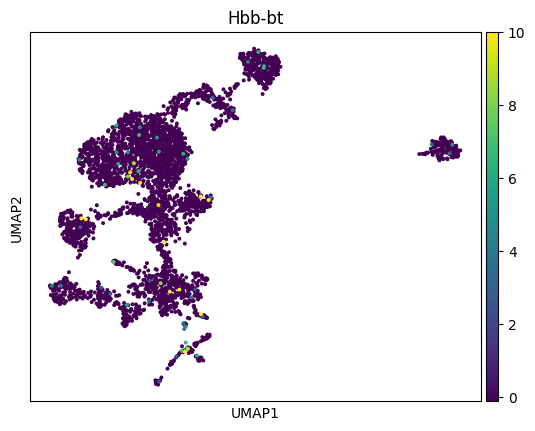

In [ ]:
# Plot UMAPS of key marker genes

genes = [
  'Sox2', 'Sox9', 'Pou1f1','Tbx19', 'Nr5a1', 'Gh', 'Prl', 'Tshb',
    'Pomc', 'Pax7', 'Lhb', 'Fshb','Mki67', 'S100b', 'Nkx2-1', 'C1qa', 'Col1a1','Pecam1', 'Hbb-bt'
]
for gene in genes:
    sc.pl.umap(adata, color=gene, title=gene)

In [ ]:
### EXPECTED CELL-TYPES AND ASSOCIATED MANUAL MARKERS

Corticotrophs - Tbx19, Pomc
Gonadotrophs - Nr5a1, Lhb, Fshb
Lactotrophs - Pou1f1, Prl
Melanotrophs - Tbx19, Pomc
Pituicytes - S100b, Sox2, Sox9
Somatotrophs - Pou1f1, Gh
Stem Cells - Sox2, Sox9
Thyrotrophs - Pou1f1, Tshb
Immune cells - C1qa
Mesenchymal cells - Col1a1
Endothelial cells - Pecam1
Erythrocytes - red blood cells - Hbb-bt